# Bài 2 - Phân lớp

Notebook này hiện hoàn thiện phần **Olist Brazilian E-Commerce - Hoàng** theo phân công trong `HUONG_DAN_LAM_BAI.md`.

**Bài toán:** dự đoán đơn hàng có giao trễ hay không (`is_late`) từ các đặc trưng thời điểm mua và quy mô/giá trị đơn hàng đã được tạo ở Bài 1.

**Yêu cầu được xử lý trong phần này:**
- Kiểm tra cột và phân phối nhãn.
- Tách train/test có `stratify=y`.
- So sánh baseline, Decision Tree, Logistic Regression và kNN.
- Thử siêu tham số bằng `GridSearchCV`.
- Báo cáo accuracy, precision, recall, F1, ROC-AUC và ma trận nhầm lẫn.
- Nhận xét kỹ thuật, đặc biệt với lớp thiểu số `is_late=True`.

## 1. Import thư viện và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Đọc dữ liệu Olist đã tiền xử lý

Input kỳ vọng được Bài 1 xuất ra tại `data/processed/olist/olist_classification.csv`.

Nếu cell dưới báo `FileNotFoundError`, chạy lại `bai-1/khao-sat.ipynb` bằng `Restart & Run All` để sinh file này trước.

In [2]:
def find_data_file(relative_path: str) -> Path:
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
        Path.cwd().parent.parent / relative_path,
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    checked = '\n'.join(str(p.resolve()) for p in candidates)
    raise FileNotFoundError(
        'Không tìm thấy file dữ liệu Olist classification. '
        'Hãy chạy lại bai-1/khao-sat.ipynb để xuất data/processed trước.\n'
        f'Các đường dẫn đã kiểm tra:\n{checked}'
    )

DATA_PATH = find_data_file('data/processed/olist/olist_classification.csv')
df = pd.read_csv(DATA_PATH)

print('DATA_PATH =', DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

DATA_PATH = C:\Users\Chien\data_mining_project\data\processed\olist\olist_classification.csv
Shape: (96476, 11)
Columns: ['order_id', 'order_purchase_timestamp', 'is_late', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'order_item_count', 'unique_product_count', 'unique_seller_count', 'total_order_price', 'total_freight_value']


,order_id,order_purchase_timestamp,is_late,purchase_month,purchase_dayofweek,purchase_hour,order_item_count,unique_product_count,unique_seller_count,total_order_price,total_freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,False,10,0,10,1.0,1.0,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,False,7,1,20,1.0,1.0,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,False,8,2,8,1.0,1.0,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,False,11,5,19,1.0,1.0,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,False,2,1,21,1.0,1.0,1.0,19.90,8.72


## 3. Kiểm tra dữ liệu và phân phối nhãn

`is_late=True` là lớp quan trọng hơn về mặt kỹ thuật trong notebook này vì đây là lớp thiểu số. Accuracy cao chưa đủ nếu mô hình bỏ sót hầu hết đơn giao trễ.

<class 'pandas.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  96476 non-null  str    
 1   order_purchase_timestamp  96476 non-null  str    
 2   is_late                   96476 non-null  bool   
 3   purchase_month            96476 non-null  int64  
 4   purchase_dayofweek        96476 non-null  int64  
 5   purchase_hour             96476 non-null  int64  
 6   order_item_count          96476 non-null  float64
 7   unique_product_count      96476 non-null  float64
 8   unique_seller_count       96476 non-null  float64
 9   total_order_price         96476 non-null  float64
 10  total_freight_value       96476 non-null  float64
dtypes: bool(1), float64(5), int64(3), str(2)
memory usage: 7.5 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,96476,96476,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,96476,95954,2018-03-31 15:08:21,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_late,96476,2,False,89941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_month,96476.0,NaN,NaN,NaN,6.03121,3.228532,1.0,3.0,6.0,8.0,12.0
purchase_dayofweek,96476.0,NaN,NaN,NaN,2.75654,1.967093,0.0,1.0,3.0,4.0,6.0
purchase_hour,96476.0,NaN,NaN,NaN,14.773032,5.328476,0.0,11.0,15.0,19.0,23.0
order_item_count,96476.0,NaN,NaN,NaN,1.142212,0.538816,1.0,1.0,1.0,1.0,21.0
unique_product_count,96476.0,NaN,NaN,NaN,1.038548,0.227965,1.0,1.0,1.0,1.0,8.0
unique_seller_count,96476.0,NaN,NaN,NaN,1.0139,0.123538,1.0,1.0,1.0,1.0,5.0
total_order_price,96476.0,NaN,NaN,NaN,137.038176,209.047091,0.85,45.9,86.5,149.9,13440.0


Tổng missing: 0


Series([], dtype: int64)

,count,rate_%
is_late,,
False,89941,93.23
True,6535,6.77


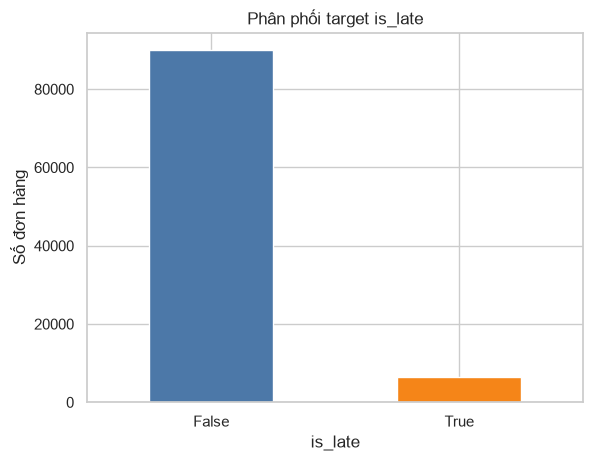

In [3]:
TARGET = 'is_late'
assert TARGET in df.columns, f'Thiếu target {TARGET}'

df.info()
display(df.describe(include='all').T)

missing = df.isna().sum().sort_values(ascending=False)
print('Tổng missing:', int(missing.sum()))
display(missing[missing > 0])

target_count = df[TARGET].value_counts(dropna=False)
target_rate = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)
display(pd.DataFrame({'count': target_count, 'rate_%': target_rate}))

ax = target_count.sort_index().plot(kind='bar', color=['#4c78a8', '#f58518'])
ax.set_title('Phân phối target is_late')
ax.set_xlabel('is_late')
ax.set_ylabel('Số đơn hàng')
plt.xticks(rotation=0)
plt.show()

## 4. Chuẩn bị train/test

Các cột định danh/thời gian thô như `order_id`, `order_purchase_timestamp` không đưa trực tiếp vào mô hình. Các biến tách từ thời gian (`purchase_month`, `purchase_dayofweek`, `purchase_hour`) đã được tạo ở Bài 1 nên được giữ lại.

In [4]:
drop_cols = [TARGET, 'order_id', 'order_purchase_timestamp']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[TARGET].astype(int)

numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()

print('Feature columns:', feature_cols)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain target rate:')
print(y_train.value_counts(normalize=True).sort_index().round(4))
print('\nTest target rate:')
print(y_test.value_counts(normalize=True).sort_index().round(4))

Feature columns: ['purchase_month', 'purchase_dayofweek', 'purchase_hour', 'order_item_count', 'unique_product_count', 'unique_seller_count', 'total_order_price', 'total_freight_value']
Numeric features: ['purchase_month', 'purchase_dayofweek', 'purchase_hour', 'order_item_count', 'unique_product_count', 'unique_seller_count', 'total_order_price', 'total_freight_value']
Categorical features: []
Train shape: (77180, 8)
Test shape: (19296, 8)

Train target rate:
is_late
0    0.9323
1    0.0677
Name: proportion, dtype: float64

Test target rate:
is_late
0    0.9323
1    0.0677
Name: proportion, dtype: float64


## 5. Pipeline tiền xử lý

Dùng `ColumnTransformer` bên trong pipeline để mọi bước impute/encode/scale chỉ được fit trên tập train, tránh rò rỉ dữ liệu test.

- Decision Tree không cần scale.
- Logistic Regression và kNN cần scale vì nhạy với độ lớn/thang đo của đặc trưng.
- Nếu có cột hạng mục phát sinh, notebook sẽ tự one-hot encode.

In [5]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    if scale_numeric:
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
    else:
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

## 6. Hàm đánh giá mô hình

In [6]:
def get_positive_score(model, X_data):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_data)
    return None


def evaluate_model(name: str, model, X_test, y_test) -> dict:
    y_pred = model.predict(X_test)
    y_score = get_positive_score(model, X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='binary',
        pos_label=1,
        zero_division=0,
    )
    auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan

    print('=' * 80)
    print(name)
    print('=' * 80)
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Dung_han', 'Tre_han'],
        zero_division=0,
    ))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('ROC-AUC:', round(auc, 4) if not np.isnan(auc) else 'N/A')

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Dung_han', 'Tre_han'],
        cmap='Blues',
    )
    plt.title(f'Ma trận nhầm lẫn - {name}')
    plt.show()

    if y_score is not None:
        RocCurveDisplay.from_predictions(y_test, y_score)
        plt.title(f'ROC curve - {name}')
        plt.show()

    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_late': precision,
        'recall_late': recall,
        'f1_late': f1,
        'roc_auc': auc,
    }

## 7. Baseline

Baseline luôn dự đoán lớp phổ biến nhất giúp kiểm tra xem accuracy có bị lớp `không trễ` chi phối không.

Baseline - Most Frequent
              precision    recall  f1-score   support

    Dung_han       0.93      1.00      0.96     17989
     Tre_han       0.00      0.00      0.00      1307

    accuracy                           0.93     19296
   macro avg       0.47      0.50      0.48     19296
weighted avg       0.87      0.93      0.90     19296

Confusion matrix:
[[17989     0]
 [ 1307     0]]
ROC-AUC: 0.5


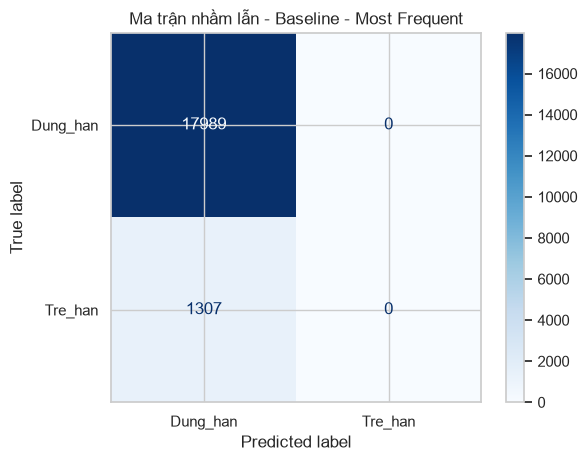

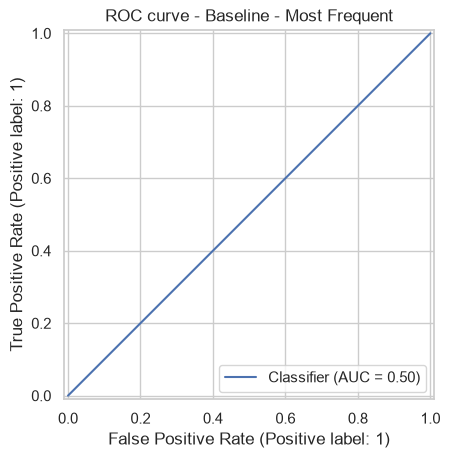

In [7]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

results = []
results.append(evaluate_model('Baseline - Most Frequent', baseline, X_test, y_test))

## 8. Decision Tree

**Giả định/cơ chế:** Decision Tree chia dữ liệu bằng các ngưỡng trên đặc trưng để làm các nút ngày càng thuần nhãn. Thuật toán không yêu cầu quan hệ tuyến tính và không cần chuẩn hóa, nhưng dễ overfit nếu cây quá sâu.

**Xử lý mất cân bằng:** thử cả `class_weight=None` và `class_weight='balanced'`; chọn theo F1 của lớp giao trễ.

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 50}
Best CV F1 late: 0.2228
Decision Tree - GridSearch
              precision    recall  f1-score   support

    Dung_han       0.96      0.76      0.85     17989
     Tre_han       0.14      0.55      0.23      1307

    accuracy                           0.75     19296
   macro avg       0.55      0.65      0.54     19296
weighted avg       0.90      0.75      0.81     19296

Confusion matrix:
[[13727  4262]
 [  594   713]]
ROC-AUC: 0.6828


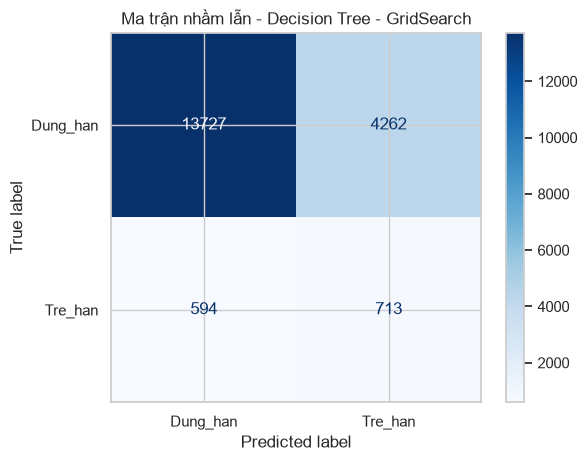

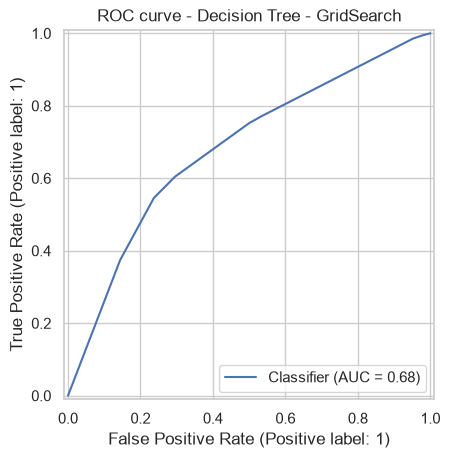

In [8]:
tree_pipe = Pipeline([
    ('preprocess', make_preprocessor(scale_numeric=False)),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

tree_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_leaf': [50, 100, 300],
    'model__class_weight': [None, 'balanced'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tree_search = GridSearchCV(
    tree_pipe,
    tree_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
tree_search.fit(X_train, y_train)

print('Best params:', tree_search.best_params_)
print('Best CV F1 late:', round(tree_search.best_score_, 4))
results.append(evaluate_model('Decision Tree - GridSearch', tree_search.best_estimator_, X_test, y_test))

## 9. Logistic Regression

**Giả định/cơ chế:** Logistic Regression học biên quyết định tuyến tính trên log-odds của xác suất giao trễ. Mô hình dễ dùng làm baseline có diễn giải, nhưng có thể thiếu linh hoạt nếu quan hệ giữa biến đầu vào và nhãn phi tuyến.

**Xử lý mất cân bằng:** thử cả không cân bằng và `class_weight='balanced'`.

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'model__C': 10.0, 'model__class_weight': 'balanced'}
Best CV F1 late: 0.1502
Logistic Regression - GridSearch
              precision    recall  f1-score   support

    Dung_han       0.95      0.56      0.71     17989
     Tre_han       0.09      0.58      0.15      1307

    accuracy                           0.56     19296
   macro avg       0.52      0.57      0.43     19296
weighted avg       0.89      0.56      0.67     19296

Confusion matrix:
[[10101  7888]
 [  550   757]]
ROC-AUC: 0.5749


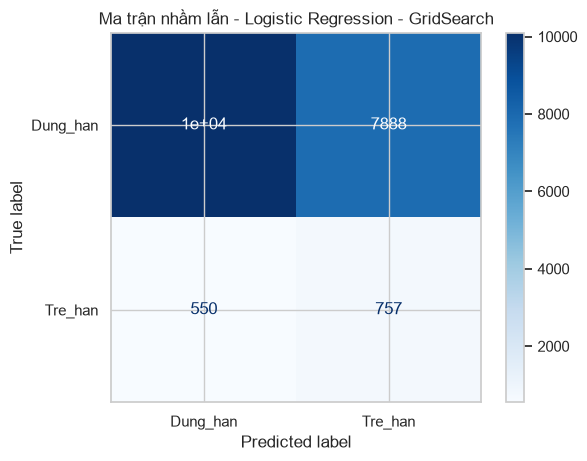

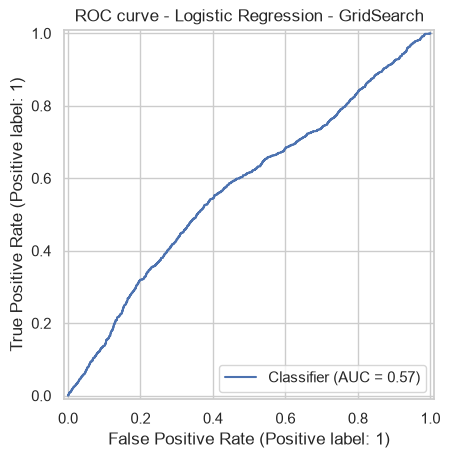

In [9]:
logreg_pipe = Pipeline([
    ('preprocess', make_preprocessor(scale_numeric=True)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

logreg_param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__class_weight': [None, 'balanced'],
}

logreg_search = GridSearchCV(
    logreg_pipe,
    logreg_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
logreg_search.fit(X_train, y_train)

print('Best params:', logreg_search.best_params_)
print('Best CV F1 late:', round(logreg_search.best_score_, 4))
results.append(evaluate_model('Logistic Regression - GridSearch', logreg_search.best_estimator_, X_test, y_test))

## 10. kNN

**Giả định/cơ chế:** kNN dự đoán nhãn của một đơn hàng dựa trên các điểm gần nhất trong không gian đặc trưng. Thuật toán phụ thuộc mạnh vào thang đo nên bắt buộc chuẩn hóa.

Vì kNN tính khoảng cách tới dữ liệu train khi dự đoán, notebook dùng mẫu train có stratify nếu tập train quá lớn để thời gian chạy ổn định.

kNN dùng mẫu train stratified 40,000 dòng để giảm thời gian chạy.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Best CV F1 late: 0.0753
kNN - GridSearch
              precision    recall  f1-score   support

    Dung_han       0.93      0.97      0.95     17989
     Tre_han       0.12      0.05      0.07      1307

    accuracy                           0.91     19296
   macro avg       0.52      0.51      0.51     19296
weighted avg       0.88      0.91      0.89     19296

Confusion matrix:
[[17466   523]
 [ 1239    68]]
ROC-AUC: 0.5409


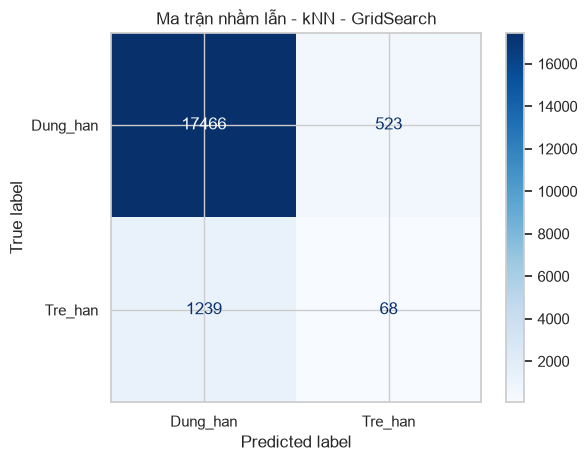

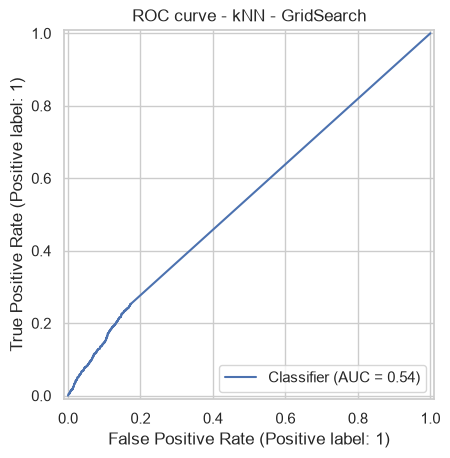

In [10]:
max_knn_train = 40000
if len(X_train) > max_knn_train:
    X_knn_train, _, y_knn_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=max_knn_train,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
    print(f'kNN dùng mẫu train stratified {len(X_knn_train):,} dòng để giảm thời gian chạy.')
else:
    X_knn_train, y_knn_train = X_train, y_train

knn_pipe = Pipeline([
    ('preprocess', make_preprocessor(scale_numeric=True)),
    ('model', KNeighborsClassifier()),
])

knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
knn_search.fit(X_knn_train, y_knn_train)

print('Best params:', knn_search.best_params_)
print('Best CV F1 late:', round(knn_search.best_score_, 4))
results.append(evaluate_model('kNN - GridSearch', knn_search.best_estimator_, X_test, y_test))

## 11. So sánh mô hình

,model,accuracy,precision_late,recall_late,f1_late,roc_auc
1,Decision Tree - GridSearch,0.7483,0.1433,0.5455,0.2270,0.6828
2,Logistic Regression - GridSearch,0.5627,0.0876,0.5792,0.1521,0.5749
3,kNN - GridSearch,0.9087,0.1151,0.0520,0.0717,0.5409
0,Baseline - Most Frequent,0.9323,0.0000,0.0000,0.0000,0.5000


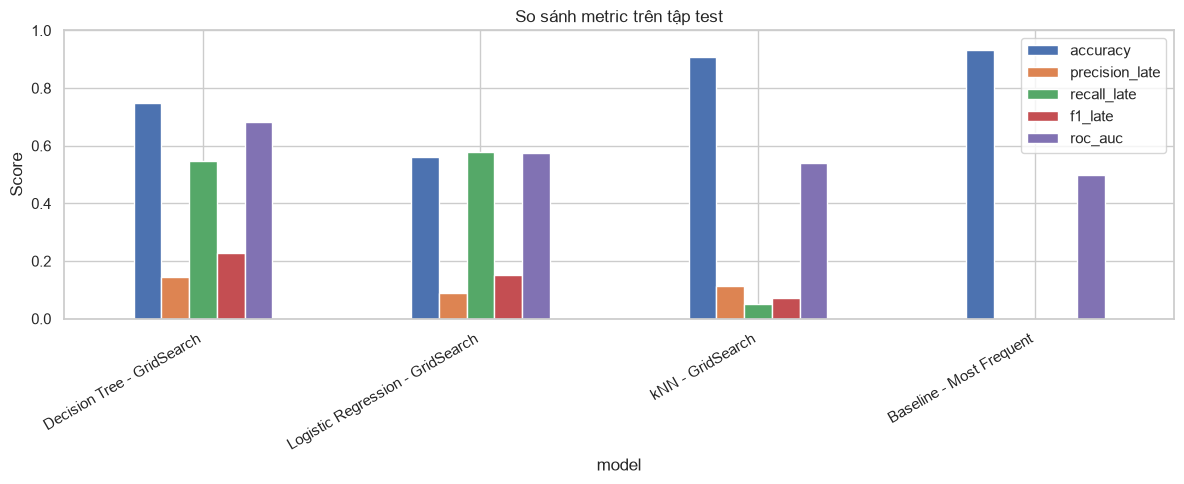

In [11]:
results_df = pd.DataFrame(results).sort_values('f1_late', ascending=False)
display(results_df.style.format({
    'accuracy': '{:.4f}',
    'precision_late': '{:.4f}',
    'recall_late': '{:.4f}',
    'f1_late': '{:.4f}',
    'roc_auc': '{:.4f}',
}))

ax = results_df.set_index('model')[['accuracy', 'precision_late', 'recall_late', 'f1_late', 'roc_auc']].plot(
    kind='bar', figsize=(12, 5)
)
ax.set_title('So sánh metric trên tập test')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12. Diễn giải kỹ thuật mô hình cây tốt nhất

Phần này chỉ dùng để nhận xét kỹ thuật ngắn: đặc trưng nào được cây dùng nhiều hơn. Không diễn giải sâu theo nghiệp vụ vì phần đó để dành cho đồ án.

,feature,importance
0,num__purchase_month,0.807007
7,num__total_freight_value,0.192993
2,num__purchase_hour,0.000000
1,num__purchase_dayofweek,0.000000
3,num__order_item_count,0.000000
4,num__unique_product_count,0.000000
5,num__unique_seller_count,0.000000
6,num__total_order_price,0.000000


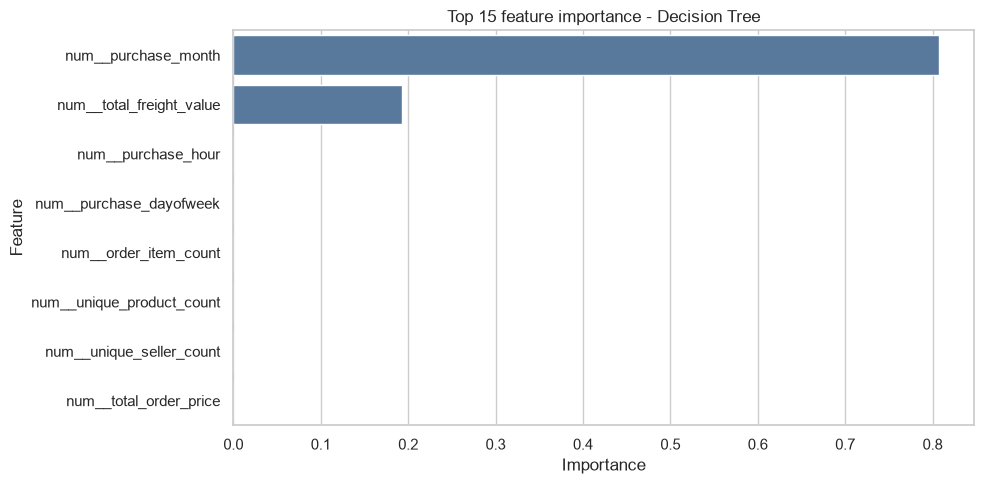

In [12]:
best_tree = tree_search.best_estimator_
preprocessor = best_tree.named_steps['preprocess']
tree_model = best_tree.named_steps['model']

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array(feature_cols)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_model.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#4c78a8')
plt.title('Top 15 feature importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 13. Nhận xét kỹ thuật để đưa vào báo cáo

- Dữ liệu Olist có mất cân bằng lớp: lớp `is_late=True` chiếm `6,77%`, nên accuracy không đủ để đánh giá mô hình.
- Baseline luôn đoán `không trễ` đạt accuracy `0,9323`, nhưng precision/recall/F1 của lớp giao trễ đều bằng `0`, vì vậy baseline không có giá trị phát hiện đơn trễ.
- Decision Tree thử `max_depth`, `min_samples_leaf` và `class_weight`; cấu hình tốt nhất là `class_weight='balanced'`, `max_depth=3`, `min_samples_leaf=50`. Mô hình này đạt F1 lớp trễ `0,2270`, recall lớp trễ `0,5455`, ROC-AUC `0,6828`, tốt nhất trong các mô hình đã thử theo F1 lớp trễ.
- Logistic Regression thử `C` và `class_weight`; cấu hình tốt nhất là `C=10.0`, `class_weight='balanced'`. Mô hình đạt recall lớp trễ `0,5792` nhưng precision chỉ `0,0876`, tạo nhiều false positive nên F1 chỉ `0,1521`.
- kNN thử `k` và `weights`; cấu hình tốt nhất là `n_neighbors=3`, `weights='distance'`. Accuracy `0,9087` nhìn khá cao, nhưng recall lớp trễ chỉ `0,0520`, tức là bỏ sót phần lớn đơn giao trễ.
- Mô hình nên được chọn theo F1/recall của lớp `is_late=True`, không chọn chỉ theo accuracy. Với các đặc trưng hiện có, Decision Tree cân bằng tốt nhất giữa khả năng phát hiện đơn trễ và mức nhiễu false positive.